# Kaggriculture Agent Development

**Washamba Bots** &mdash; development and evaluation notebook for `nikaangukia_meroni`,
our agent for the Kaggle Kaggriculture simulation competition.

Two agents each manage a farm across a 30-day season (720 turns) and compete for the
higher closing bank balance. There is no static train/test split: every result comes
from running live episodes.

This notebook covers the full working loop we use to develop the agent:

| Section | Purpose |
|---|---|
| 1. Environment setup | Install and pin the simulator, verify the runtime |
| 2. The simulation | Read the authoritative game parameters from the engine |
| 3. Observation schema | Inspect what the agent actually receives each turn |
| 4. Agent under test | Load the current agent from `main.py` |
| 5. Evaluation methodology | Seeded batches, and why single episodes mislead |
| 6. Results | Performance against all three reference opponents |
| 7. Built-ins vs. self-play | Why local numbers overstate ladder performance |
| 8. Behavioural diagnostics | Where turns go, and what the farm looks like at season end |
| 9. Findings | What the measurements taught us |
| 10. Next steps | Prioritised backlog |

**Prerequisite.** Select the `Python 3.13 (washamba_bots)` kernel. If it is not listed,
register it once from the project root:

```bash
.venv/Scripts/python.exe -m ipykernel install --user \
    --name washamba-bots --display-name "Python 3.13 (washamba_bots)"
```

## 1. Environment setup

The engine is patched mid-competition. A balance change in August 2026 reduced Town
Center demand and made shop unlocks sample *with* replacement, so competition staff
directed everyone to `kaggle-environments >= 1.32.6`. The official starter notebook
still pins `>= 1.32.2`, which predates that patch &mdash; do not copy it.

**There is no install cell here on purpose.** This environment is provisioned by
`uv`, which does not put `pip` inside the venv, so `%pip install ...` prints
"No module named pip" and silently does nothing &mdash; an install cell that
looks like it ran. The cell below asserts the version instead and raises if the
pin is unmet, with the `uv` command to fix it.

If you do install from a notebook elsewhere, use `%pip`, never `!pip`: `%pip`
targets the running kernel, while `!pip` shells out to whatever is first on
`PATH`. That mismatch is how a notebook ends up reporting
`No module named kaggle_environments` while the venv sits there working.


In [1]:
# This venv is provisioned by `uv` and deliberately ships no `pip`, so an
# install cell here would print "No module named pip" and silently do
# nothing. Assert the pin instead, so a wrong version fails loudly rather
# than quietly scoring a different game than the one we think we're playing.
from importlib.metadata import version

REQUIRED = (1, 32, 6)
installed = tuple(int(part) for part in version("kaggle-environments").split(".")[:3])

required_text = ".".join(map(str, REQUIRED))
installed_text = ".".join(map(str, installed))

if installed < REQUIRED:
    raise RuntimeError(f"""kaggle-environments {installed_text} predates the
August 2026 balance patch. Install the pin from a terminal, not from this
notebook:

    uv pip install --python .venv/Scripts/python.exe \
        'kaggle-environments>={required_text}'

(Use .venv/bin/python on macOS.)""")

print(f"kaggle-environments {installed_text} satisfies the >= {required_text} pin.")

kaggle-environments 1.32.7 satisfies the >= 1.32.6 pin.


In [2]:
import platform
from importlib.metadata import version

from kaggle_environments import make

print(f"Python              {platform.python_version()}")
print(f"kaggle-environments {version('kaggle-environments')}")

Python              3.13.7
kaggle-environments 1.32.7


## 2. The simulation

Competition staff have been explicit that **the engine is the source of truth**: the
published documentation and the implementation have disagreed more than once over the
season, and the engine wins every time.

So rather than restating constants from the docs, we read them from the environment
that will actually score us.

In [3]:
env = make("kaggriculture", debug=False)
config = env.configuration

PARAMETERS_OF_INTEREST = [
    ("episodeSteps", "Turns per season"),
    ("turnsPerDay", "Turns per in-game day"),
    ("boardSize", "Farm width/height in tiles"),
    ("startingMoney", "Opening bank balance"),
    ("shedCapacity", "Non-seed storage cap"),
    ("maxMarketOrdersPerTurn", "Market orders processed per turn"),
    ("actTimeout", "Seconds allowed per turn"),
    ("weedSpawnChance", "Per-tile daily weed chance"),
    ("farmHandCostMult", "Multiplier on the hire cost sequence"),
]

print(f"{'Parameter':26s} {'Value':>10s}   Meaning")
print("-" * 78)
for key, meaning in PARAMETERS_OF_INTEREST:
    print(f"{key:26s} {str(config.get(key)):>10s}   {meaning}")

Parameter                       Value   Meaning
------------------------------------------------------------------------------
episodeSteps                      720   Turns per season
turnsPerDay                        24   Turns per in-game day
boardSize                          10   Farm width/height in tiles
startingMoney                    3000   Opening bank balance
shedCapacity                      100   Non-seed storage cap
maxMarketOrdersPerTurn             10   Market orders processed per turn
actTimeout                          1   Seconds allowed per turn
weedSpawnChance                 0.005   Per-tile daily weed chance
farmHandCostMult                    1   Multiplier on the hire cost sequence


Two of these constrain agent design far more than the rest.

**`actTimeout` is 1 second per turn**, with a 60-second overage bank for the whole
episode (readable at runtime as `obs["remainingOverageTime"]`). That rules out any
per-turn deep search; the agent must decide with cheap, local reasoning.

**`maxMarketOrdersPerTurn` is 10, and surplus orders are dropped silently** &mdash; no
exception, no warning. An agent that emits twelve orders simply loses two of them.

## 3. Observation schema

Each turn the agent receives a single `obs` dictionary and returns one action per unit
plus a list of market orders.

The critical detail is an axis convention that does not match between two fields:
**`tiles` is row-major (`tiles[y][x]`), while unit positions are `[x, y]`.** Indexing
one with the other produces no error &mdash; just an agent that quietly works the wrong
tile.

In [4]:
env = make("kaggriculture", configuration={"episodeSteps": 24}, debug=False)
env.run(["starter", "starter"])

observation = env.steps[1][0].observation
farm = observation["farms"][observation["player"]]

print("Top-level observation keys:")
print("  " + ", ".join(sorted(observation.keys())))

print("\nPublic farm state (both players visible):")
for field in ["money", "farmer", "hands", "unlocked_quadrants", "hires_today"]:
    print(f"  {field:20s} {farm[field]}")

print("\nPrivate state (ours only - the opponent's shed is never visible):")
for field, contents in observation["private"].items():
    print(f"  {field:20s} {contents}")

Top-level observation keys:
  day, farms, hour, market, player, private, remainingOverageTime, step, town

Public farm state (both players visible):
  money                2980.0
  farmer               [4, 4]
  hands                []
  unlocked_quadrants   ['NW']
  hires_today          0

Private state (ours only - the opponent's shed is never visible):
  shed                 {'WHEAT': 0, 'CARROT': 0, 'TOMATO': 0, 'STRAWBERRY': 0, 'MELON': 0, 'EGG': 0, 'MILK': 0, 'WOOL': 0, 'FERTILIZER': 0, 'GOOSE': 0, 'COW': 0, 'SHEEP': 0}
  seeds                {'WHEAT': 0, 'CARROT': 1, 'TOMATO': 0, 'STRAWBERRY': 0, 'MELON': 0}
  inventories          [{}]


A tile is one of five shapes, and the `kind` key must be checked before assuming any
structure: `None` (empty and unlocked), the string `"LOCKED"`, a plant dictionary, a
weed dictionary, or an animal structure (coop or pasture).

In [5]:
from collections import Counter


def describe_tiles(farm):
    """Summarise a farm grid by tile kind."""
    kinds = Counter()
    for row in farm["tiles"]:
        for tile in row:
            if tile is None:
                kinds["empty"] += 1
            elif isinstance(tile, str):
                kinds[tile.lower()] += 1
            else:
                kinds[tile.get("kind", "unknown").lower()] += 1
    return kinds


for kind, count in describe_tiles(farm).most_common():
    print(f"  {kind:10s} {count:3d}")

  locked      75
  empty       25


## 4. Agent under test

The agent lives in `main.py` at the repository root, which is also exactly what gets
submitted to Kaggle. The notebook imports that file rather than duplicating strategy
code, so what we measure here is what competes.

One submission rule is worth stating because it fails silently: the framework selects
**the last callable in the module namespace**, not a function named `agent`. A helper
function or class defined below the agent silently becomes the submission, the episode
still reports `DONE`, and the agent finishes on exactly its starting money.

Every unit &mdash; the main farmer and every hired hand alike &mdash; shares one
reactive priority ladder, re-evaluated from scratch each turn, with a per-turn claim
set so units spread out instead of converging on the same tile:

1. Feed an animal underfoot &mdash; ahead of even a ready harvest. A missed feeding is
   a permanent loss (the animal escapes for good), and it silently forfeits the CARE
   bank too, which only pays out on a day the animal was also fed.
2. Harvest a ripe crop, or an animal whose held yield is near its cap (collecting its
   fertilizer first, since that is a separate output).
3. Water a crop, or care for an already-fed animal, underfoot.
4. Place a carried animal on the empty coop/pasture underfoot.
5. Run shed errands: collect a bought animal waiting for its home, or several days of
   wheat to go feed an animal elsewhere.
6. Move toward urgent work elsewhere (an animal to feed, a ripe crop, a crop about to
   weed out) before anything below.
7. Carry a picked-up animal toward its coop/pasture if not there yet.
8. Dig a weed underfoot for free, reclaiming dead land.
9. Build a coop (if still growing the animal side of the farm) or plant a sensible crop
   when standing on empty ground.
10. Reclaim the nearest weed elsewhere &mdash; dead land is a permanent loss.
11. Otherwise walk toward the closest useful tile.
12. `PASS` if there is genuinely nothing useful to do.

This is the authoritative list straight from `main.py`'s module docstring &mdash;
re-read that docstring after any strategy change rather than trusting this copy, since
it is exactly what is re-read to keep this cell honest.

In [6]:
import pathlib
import subprocess
import sys


def locate_repository():
    """Find main.py locally, or clone the repo when running on Kaggle/Colab."""
    for candidate in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (candidate / "main.py").exists():
            return candidate

    target = pathlib.Path("washamba_bots")
    if not target.exists():
        subprocess.run(
            ["git", "clone", "-q", "https://github.com/Kinjuriu/washamba_bots.git"],
            check=True,
        )
    return target.resolve()


REPO = locate_repository()
AGENT_PATH = str(REPO / "main.py")

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import main

print(f"Repository: {REPO}")
print(f"Submitted entry point resolves to: {main.agent.__name__}")

Repository: C:\Users\HP\Spidey-Hub\washamba_bots
Submitted entry point resolves to: nikaangukia_meroni


## 5. Evaluation methodology

**A single episode cannot distinguish an improvement from luck.** Run-to-run spread on
an identical agent has exceeded 1,400 bank on the same matchup, which is larger than
most changes we would like to detect.

Two rules follow, and both are load-bearing:

1. **Always evaluate over a batch of fixed seeds**, and report the mean and win rate
   rather than any individual score.
2. **A/B strategy changes against `pass` and `starter`.** Passing a `seed` makes the
   *environment* deterministic &mdash; weed spawns and shop unlocks &mdash; but it does
   not control the built-in `random` agent's own RNG, so that opponent still drifts
   between runs on an identical seed.

In [7]:
import statistics


def evaluate(agent_path, opponent, seeds, episode_steps=720):
    """Play one seeded episode per seed and collect the closing balances."""
    rows = []
    for seed in seeds:
        env = make(
            "kaggriculture",
            configuration={"episodeSteps": episode_steps, "seed": seed},
            debug=False,
        )
        env.run([agent_path, opponent])
        ours, theirs = env.steps[-1]
        rows.append(
            {
                "opponent": opponent,
                "seed": seed,
                "ours": ours.reward,
                "theirs": theirs.reward,
                "won": ours.reward > theirs.reward,
            }
        )
    return rows


def summarise(rows):
    """Reduce per-episode rows to the numbers worth reporting."""
    ours = [row["ours"] for row in rows]
    return {
        "episodes": len(rows),
        "mean": round(statistics.mean(ours)),
        "stdev": round(statistics.stdev(ours)) if len(ours) > 1 else 0,
        "min": round(min(ours)),
        "max": round(max(ours)),
        "wins": sum(row["won"] for row in rows),
    }

### Running the batch

Each 720-turn episode takes roughly seven seconds. `SEEDS` below is deliberately small
so the notebook stays responsive; **use twelve or more seeds before acting on a
result.** The three built-in opponents are `pass` (does nothing, banks its opening
3,000), `random`, and `starter` (a deterministic reference agent).

In [8]:
SEEDS = range(4)
OPPONENTS = ["pass", "random", "starter"]

per_seed = {}
results = {}
for opponent in OPPONENTS:
    per_seed[opponent] = evaluate(AGENT_PATH, opponent, SEEDS)
    results[opponent] = summarise(per_seed[opponent])
    print(f"  {opponent:8s} complete")

  pass     complete


  random   complete


  starter  complete


## 6. Results

### Visual conventions

Every figure below draws from one small validated palette, applied in a fixed order
so a given colour always means the same thing across charts. The three hues clear
colourblind-separation and normal-vision thresholds as a set. Grid lines and axes stay
recessive so the data carries the emphasis, and no chart uses two y-axes &mdash; where
two measures have different units they get separate figures.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_MUTED = "#52514e"
GRID = "#e5e4e0"

# Fixed categorical order - assigned by position, never cycled.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_MUTED,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.size": 10,
    "figure.dpi": 110,
})


def finish(ax, title, xlabel=None, ylabel=None, legend=False):
    """Apply the shared title/label/legend treatment to an axis."""
    ax.set_title(title, fontsize=12.5, color=INK, pad=12, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if legend:
        ax.legend(frameon=False, labelcolor=INK_MUTED)
    plt.tight_layout()


STARTING_MONEY = config.get("startingMoney", 3000)

summary = pd.DataFrame(results).T
summary.index.name = "opponent"
summary

,episodes,mean,stdev,min,max,wins
opponent,,,,,,
pass,4,52718,3835,47292,55562,4
random,4,52485,3432,47925,56080,4
starter,4,51570,3974,47310,56318,4


### Distribution across seeds

A bar of means would hide the thing that matters most here: **spread**. Each dot is one
seeded episode, so the vertical scatter within a column is exactly the run-to-run noise
that makes single-episode comparisons untrustworthy.

The dashed line is the opening balance. It is the floor that counts &mdash; an agent
finishing below it has destroyed value relative to doing nothing at all, which an
earlier revision of this agent genuinely did on unlucky seeds.

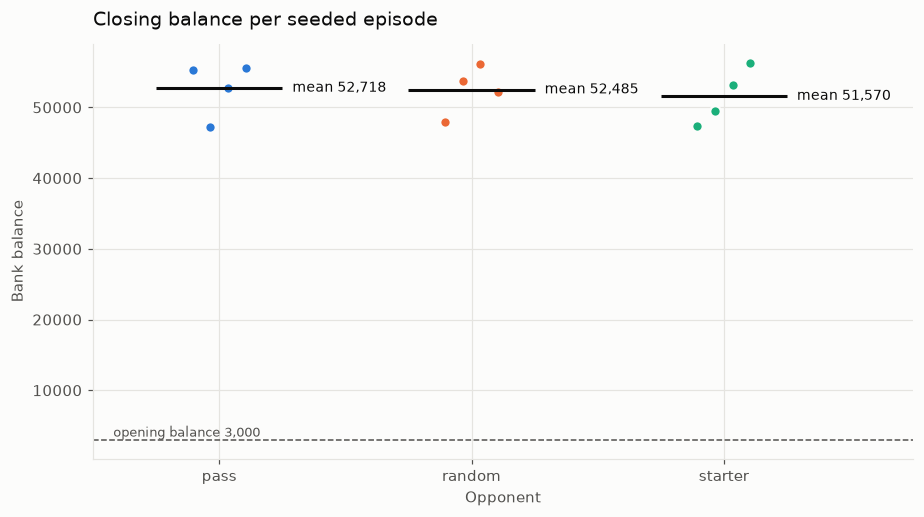

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

for index, opponent in enumerate(OPPONENTS):
    balances = [row["ours"] for row in per_seed[opponent]]
    offsets = [
        index + (position - (len(balances) - 1) / 2) * 0.07
        for position in range(len(balances))
    ]
    ax.scatter(
        offsets, balances,
        s=48, color=SERIES[index], zorder=3,
        edgecolor=SURFACE, linewidth=1.5,
    )

    mean_balance = statistics.mean(balances)
    ax.hlines(mean_balance, index - 0.25, index + 0.25,
              color=INK, linewidth=2, zorder=4)
    ax.text(index + 0.29, mean_balance, f"mean {mean_balance:,.0f}",
            va="center", fontsize=9, color=INK)

ax.axhline(STARTING_MONEY, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
ax.text(-0.42, STARTING_MONEY, f"opening balance {STARTING_MONEY:,}",
        va="bottom", fontsize=8.5, color=INK_MUTED)

ax.set_xticks(range(len(OPPONENTS)))
ax.set_xticklabels(OPPONENTS)
ax.set_xlim(-0.5, len(OPPONENTS) - 0.25)

finish(ax, "Closing balance per seeded episode",
       xlabel="Opponent", ylabel="Bank balance")
plt.show()

## 7. Built-ins vs. self-play

Section 6 measured us against `pass`, `random`, and `starter` &mdash; but all three
share one property that matters more than any individual matchup: **none of them ever
issues a `SELL` order.** They leave the market sitting at its pristine starting
inventory for the whole season. Every sale we make lands in a market that has never
absorbed a competitor's supply, so prices stay high all season &mdash; MELON in
particular can close a `starter` matchup near its full, uncompeted price, because
nobody else is pushing it toward the floor.

Self-play removes that artifact. Both sides sell into the *same* shared market, so the
same MELON that finishes near $280 against a built-in collapses toward the $1 floor
once another equally aggressive seller is unloading a full harvest into it too. That is
a mechanical consequence of the engine's pricing curve (`docs/kaggriculture_context.md`
&sect;3.10), not a bug in either agent.

This is why the local benchmark and the Kaggle ladder disagree so sharply: the same
agent that clears roughly 42,000&ndash;43,000 mean bank against the three built-ins
(Section 6, twelve seeds) drops to roughly 27,000 in self-play (six seeds) &mdash; a gap
of about 15,000 driven almost entirely by price competition the built-in matchups never
exercise. Every real opponent on the Kaggle ladder is a submitted agent, not
`pass`/`random`/`starter`, so **self-play is the better predictor of ladder
performance.** It is why a ~33,000-mean local agent still scored 467.4 against a
leaderboard median of 744.5 (Section 9).

We use four seeds below, not twelve, to keep this cell's runtime sane &mdash; self-play
alone is two full 720-turn episodes per seed. Treat the chart as a demonstration of the
mechanism, not a precision estimate; Section 6's own numbers remain the ones to act on
for built-in-only comparisons.

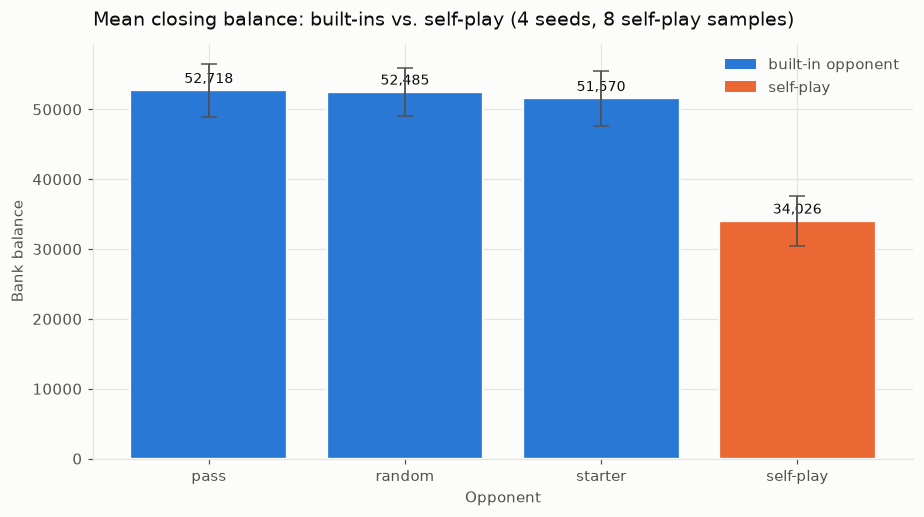

,mean,stdev
pass,52718,3835
random,52485,3432
starter,51570,3974
self-play,34026,3559


In [11]:
def evaluate_self_play(agent_path, seeds, episode_steps=720):
    """Play one seeded self-play episode per seed. Both sides run the same
    agent, and both sides' closing balances count as independent samples."""
    balances = []
    for seed in seeds:
        env = make(
            "kaggriculture",
            configuration={"episodeSteps": episode_steps, "seed": seed},
            debug=False,
        )
        env.run([agent_path, agent_path])
        left, right = env.steps[-1]
        balances.extend([left.reward, right.reward])
    return balances


SELF_PLAY_SEEDS = range(4)
self_play_balances = evaluate_self_play(AGENT_PATH, SELF_PLAY_SEEDS)

comparison = {
    opponent: {"mean": results[opponent]["mean"], "stdev": results[opponent]["stdev"]}
    for opponent in OPPONENTS
}
comparison["self-play"] = {
    "mean": round(statistics.mean(self_play_balances)),
    "stdev": round(statistics.stdev(self_play_balances)) if len(self_play_balances) > 1 else 0,
}

labels = list(comparison.keys())
means = [comparison[label]["mean"] for label in labels]
stdevs = [comparison[label]["stdev"] for label in labels]
# Two hues carry the meaning that matters: built-in opponent vs. self-play.
# Individual opponent identity is already carried by the x-tick labels.
colors = [SERIES[0]] * len(OPPONENTS) + [SERIES[1]]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    labels, means, yerr=stdevs, capsize=5, color=colors,
    edgecolor=SURFACE, linewidth=1.5, zorder=3,
    error_kw={"ecolor": INK_MUTED, "elinewidth": 1.2},
)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + max(means) * 0.02,
            f"{mean:,.0f}", ha="center", fontsize=9, color=INK)

finish(
    ax,
    f"Mean closing balance: built-ins vs. self-play "
    f"({len(SELF_PLAY_SEEDS)} seeds, {len(self_play_balances)} self-play samples)",
    xlabel="Opponent", ylabel="Bank balance",
)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(facecolor=SERIES[0], label="built-in opponent"),
        Patch(facecolor=SERIES[1], label="self-play"),
    ],
    frameon=False, labelcolor=INK_MUTED,
)
plt.show()

pd.DataFrame(comparison).T

## 8. Behavioural diagnostics

Aggregate scores say whether a change helped. They do not say why. For that we replay a
single episode and record how it unfolded: the balance over time, the state of the
farm, and where the turns went.

One episode is the right unit here &mdash; we are reading mechanism, not measuring
performance.

In [12]:
def profile_episode(agent_path, opponent, seed):
    """Replay one episode, recording per-day history and end state."""
    env = make(
        "kaggriculture",
        configuration={"episodeSteps": 720, "seed": seed},
        debug=False,
    )
    env.run([agent_path, opponent])

    turns_per_day = config.get("turnsPerDay", 24)
    unit_actions = Counter()
    market_orders = Counter()
    sold_units = Counter()
    history = []

    for index, step in enumerate(env.steps):
        action = step[0].get("action") or {}
        farmer = action.get("farmer") or []
        if farmer:
            unit_actions[farmer[0]] += 1
        for hand in action.get("hands") or []:
            if hand:
                unit_actions[hand[0]] += 1
        for order in action.get("market") or []:
            if order:
                market_orders[order[0]] += 1
                # SELL orders are ["SELL", product, quantity] and, unlike the
                # count of order *objects*, are not subject to the 10-orders-
                # per-turn cap - the engine fills a SELL's whole requested
                # quantity in one lockstep loop as long as our shed holds it,
                # which our own agent guarantees by construction. Summing
                # order[2] here is therefore units actually sold, not just
                # requested.
                if order[0] == "SELL" and len(order) >= 3:
                    sold_units[order[1]] += order[2]

        # Sample once per in-game day to keep the series readable.
        if index % turns_per_day == 0:
            observation = step[0].observation
            tiles = describe_tiles(observation["farms"][0])
            history.append({
                "day": index // turns_per_day,
                "ours": observation["farms"][0]["money"],
                "theirs": observation["farms"][1]["money"],
                "plants": tiles.get("plant", 0),
                "weeds": tiles.get("weed", 0),
                "empty": tiles.get("empty", 0),
                **{f"price_{k}": v for k, v in observation["market"]["prices"].items()},
            })

    final = env.steps[-1][0]
    return {
        "balance": final.reward,
        "unit_actions": unit_actions,
        "market_orders": market_orders,
        "sold_units": sold_units,
        "final_farm": final.observation["farms"][0],
        "history": pd.DataFrame(history).set_index("day"),
    }


profile = profile_episode(AGENT_PATH, "starter", seed=0)
timeline = profile["history"]

print(f"Closing balance: {profile['balance']:,.0f}\n")
print("Market orders issued:")
for order, count in profile["market_orders"].most_common():
    print(f"  {order:12s} {count:4d}")

print("\nFarm at season end:")
for kind, count in describe_tiles(profile["final_farm"]).most_common():
    print(f"  {kind:12s} {count:4d}")

Closing balance: 47,310

Market orders issued:
  HIRE          154
  BUY_SEED      120
  SELL           86
  BUY_PRODUCT    74
  BUY_ANIMAL      1

Farm at season end:
  locked         75
  empty          21
  plant           3
  pasture         1


### Where the season is won or lost

Closing balance is a single number at turn 720; this is the path it took. Divergence
that opens early and never closes points at a structural problem, while a flat stretch
means the agent stopped converting harvests into cash.

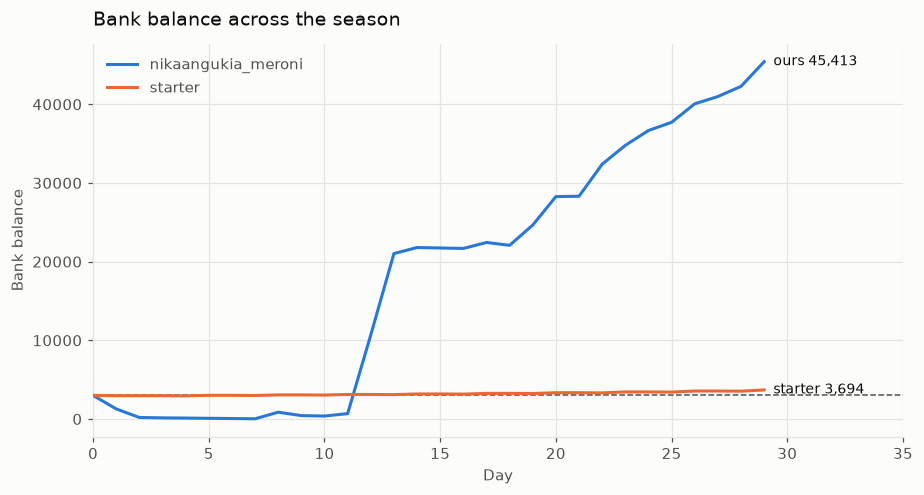

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))

ax.plot(timeline.index, timeline["ours"], color=SERIES[0],
        linewidth=2, label="nikaangukia_meroni", zorder=3)
ax.plot(timeline.index, timeline["theirs"], color=SERIES[1],
        linewidth=2, label="starter", zorder=3)

ax.axhline(STARTING_MONEY, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)

# Direct labels at the line ends, so identity never rests on colour alone.
for column, colour, name in [("ours", SERIES[0], "ours"),
                             ("theirs", SERIES[1], "starter")]:
    ax.text(timeline.index[-1] + 0.4, timeline[column].iloc[-1],
            f"{name} {timeline[column].iloc[-1]:,.0f}",
            va="center", fontsize=9, color=INK)

ax.set_xlim(0, timeline.index[-1] + 6)
finish(ax, "Bank balance across the season",
       xlabel="Day", ylabel="Bank balance", legend=True)
plt.show()

### Farm health over time

This is the chart that explains the balance curve. Tiles are a fixed budget, so the
question is what fraction is productive on any given day.

**Weeds are the signal to watch.** A weeded tile is dead ground until it is dug back,
and a rising weed band means the crew is planting faster than it can maintain &mdash;
every tile in that band is capital already spent and now earning nothing.

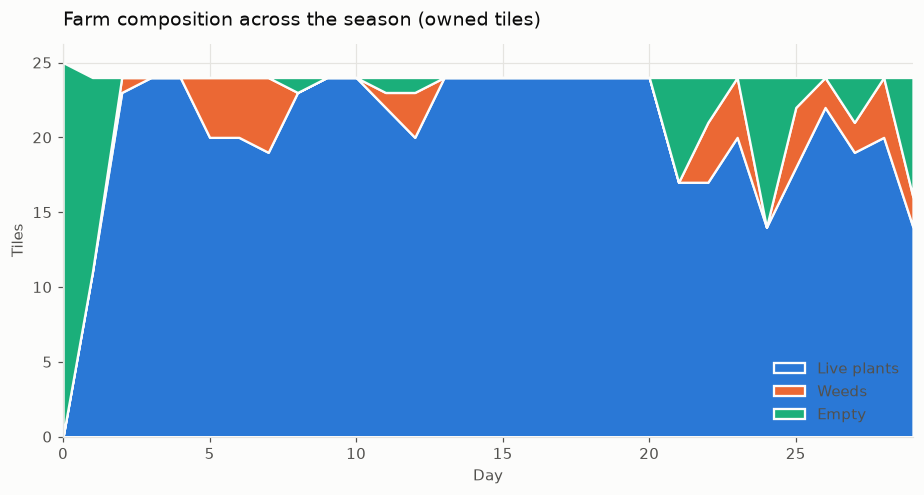

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))

ax.stackplot(
    timeline.index,
    timeline["plants"], timeline["weeds"], timeline["empty"],
    labels=["Live plants", "Weeds", "Empty"],
    colors=SERIES,
    edgecolor=SURFACE,
    linewidth=1.5,
)

ax.set_xlim(timeline.index[0], timeline.index[-1])
ax.set_ylim(0, None)
finish(ax, "Farm composition across the season (owned tiles)",
       xlabel="Day", ylabel="Tiles", legend=True)
plt.show()

### Where the turns go

Every unit gets exactly one action per turn, so the season is a fixed budget of turns
split across the farmer and any hired hands. Movement is the overhead line: turns spent
walking are turns not spent watering, digging, or harvesting.

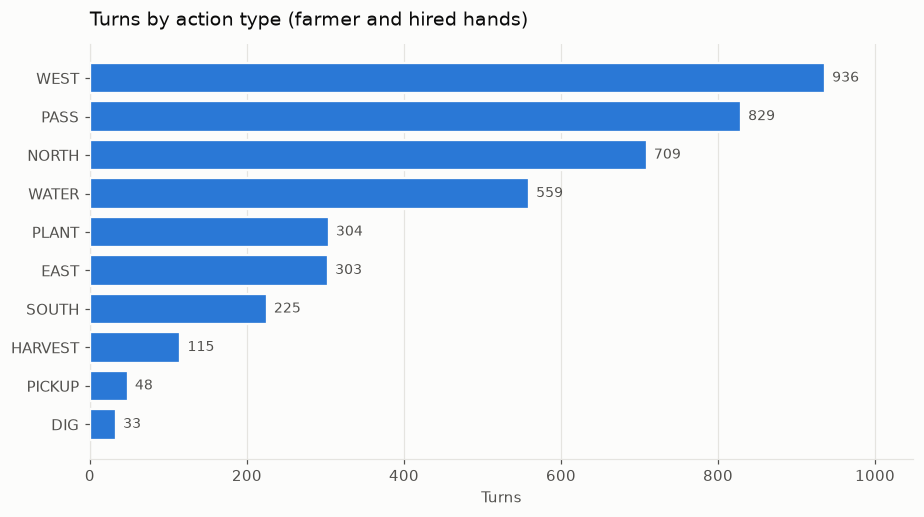

In [15]:
actions = profile["unit_actions"].most_common(10)
labels = [name for name, _ in actions][::-1]
values = [count for _, count in actions][::-1]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(labels, values, color=SERIES[0], edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.xaxis.grid(True)
ax.yaxis.grid(False)

for position, value in enumerate(values):
    ax.text(value + max(values) * 0.01, position, f"{value:,}",
            va="center", fontsize=9, color=INK_MUTED)

ax.set_xlim(0, max(values) * 1.12)
finish(ax, "Turns by action type (farmer and hired hands)", xlabel="Turns")
plt.show()

### Market response to our selling

Sale prices move with market inventory, and both players' orders clear one unit at a
time against the same book. Premium goods fall toward the floor fast on oversupply, so
a price line that sags after our harvests is direct evidence that we are selling too
much at once and should spread those orders out.

This replay is against `starter`, which never sells (Section 7), so these are
*uncompeted* prices &mdash; the ceiling case, not what we should expect against a real
ladder opponent. MELON and EGG each get their own panel rather than sharing one with
the staples: MELON swings across the widest range of anything we track, while EGG
moves in a narrow band because volume is capped by a single goose (Section 8, animal
husbandry) &mdash; sharing an axis with either would flatten the other into an
unreadable line.

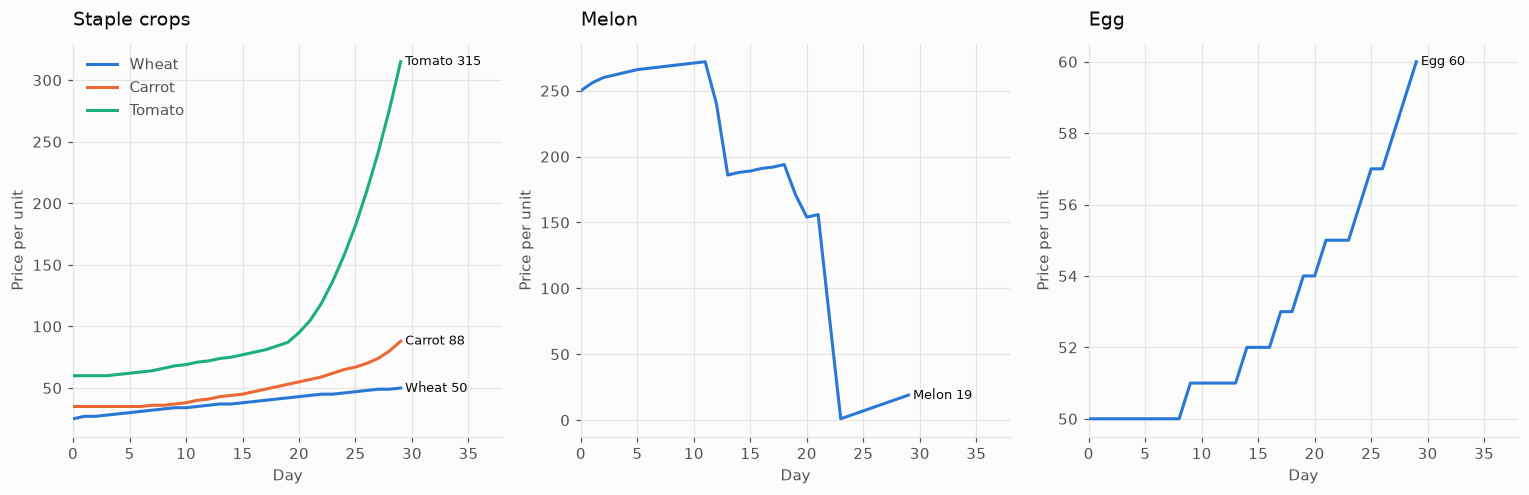

In [16]:
PANELS = [
    ("Staple crops", ["WHEAT", "CARROT", "TOMATO"]),
    ("Melon", ["MELON"]),
    ("Egg", ["EGG"]),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

for ax, (title, products) in zip(axes, PANELS):
    columns = [
        f"price_{product}" for product in products
        if f"price_{product}" in timeline.columns
    ]
    for index, column in enumerate(columns):
        product = column.removeprefix("price_")
        ax.plot(timeline.index, timeline[column], color=SERIES[index],
                linewidth=2, label=product.title(), zorder=3)
        ax.text(timeline.index[-1] + 0.4, timeline[column].iloc[-1],
                f"{product.title()} {timeline[column].iloc[-1]:,.0f}",
                va="center", fontsize=8.5, color=INK)
    ax.set_xlim(0, timeline.index[-1] + 9)
    finish(ax, title, xlabel="Day", ylabel="Price per unit", legend=len(columns) > 1)

plt.show()

### Animal husbandry

Feeding is priority #1 in the agent's ladder (Section 4), ahead of even harvesting a
ready crop, for a mechanical reason: the engine's `_daily_refresh_animals` removes an
animal permanently, with no recovery path, after two consecutive unfed days. A weed can
be dug back up; an escaped animal cannot.

`CARE` has the same trap in a quieter form. Its `+1` only banks on a day the animal was
*both* fed and cared for, and the whole banked bonus only pays out on the animal's next
production day *if that day is also a fed day* &mdash; otherwise the bank is discarded
unpaid. An earlier agent fed on alternate days and threw away most of its care bonus
without any visible symptom.

**That mechanic is also what chooses the species.** Because the bank pays out in full on
the next production day, a *longer* interval banks a *bigger* payout:

| animal | interval | units per event | events | total units | net after cost |
|---|---|---|---|---|---|
| GOOSE | 1 | 2 | 26 | 52 | $2,023 |
| COW | 2 | 3 | 11 | 33 | $3,704 |
| **SHEEP** | 3 | **4** | 8 | 32 | **$5,236** |

The goose row is the model's check: it predicts 52 egg units, and 52 is what we
measured before switching. A new species also needs its own `SELL_PRICE_THRESHOLDS` and
`MAX_SELL_PER_TURN` entries, or it falls back to the default threshold and dumps into a
curve that floors after 58 units.

Only **one** animal, though. Two of anything &mdash; even a sheep and a cow, which sell
into completely separate markets &mdash; measured **-16,634, losing 16 of 16 matches**.
Every structure costs a crop tile and a share of the crew's upkeep capacity.

In [17]:
from main import ACTIVE_ANIMALS, ANIMALS

SPECIES = ACTIVE_ANIMALS[0]
PRODUCT = ANIMALS[SPECIES]["product"]


def animal_present(farm):
    """True if any tile still holds a live animal (not just an empty structure)."""
    return any(
        isinstance(tile, dict) and "animal" in tile
        for row in farm["tiles"] for tile in row
    )


feed_count = profile["unit_actions"].get("FEED", 0)
care_count = profile["unit_actions"].get("CARE", 0)
product_sold = profile["sold_units"].get(PRODUCT, 0)
alive = animal_present(profile["final_farm"])

# What the care-bank model predicts, so the measurement has something to check.
info = ANIMALS[SPECIES]
events = len([d for d in range(info["first_yield_day"], 30)
              if (d - info["first_yield_day"]) % info["interval"] == 0])
per_event = min(info["max_held"], 1 + info["interval"])

print(f"species                {SPECIES} -> {PRODUCT}")
print(f"{'FEED actions':22s} {feed_count:4d}   (30 = fed every day)")
print(f"{'CARE actions':22s} {care_count:4d}")
print(f"{PRODUCT + ' units sold':22s} {product_sold:4d}   (model predicts {events * per_event})")
print(f"{'alive at season end':22s} {str(alive):>4s}")

species                SHEEP -> WOOL
FEED actions             30   (30 = fed every day)
CARE actions             30
WOOL units sold          34   (model predicts 32)
alive at season end    True


### Where the demand actually is

Everything above is the supply side. The demand side turned out to be the single
biggest lever of the project, and we had been ignoring it entirely.

Two mechanics in `_town_consume` do the work. Town **shops** fire every
`townShopSellInterval` steps (4 by default, so six times a day) while the **Town
Centre** buys one of every product once a day &mdash; so a single unlocked shop is
worth roughly six Town Centres. A shop that sells exactly **one** product consumes it
at **double** rate, and shops are drawn **with replacement**, so the same shop can be
unlocked several times and each instance consumes independently.

Read the `SHOPS` table against that and one crop stands out by its absence.

product      shops  demand/day
WHEAT            5          31
STRAWBERRY       4          25
CARROT           2          19
MILK             3          19
TOMATO           2          13
EGG              2          13
WOOL             1          13
MELON            0           1   <-- no shop at all


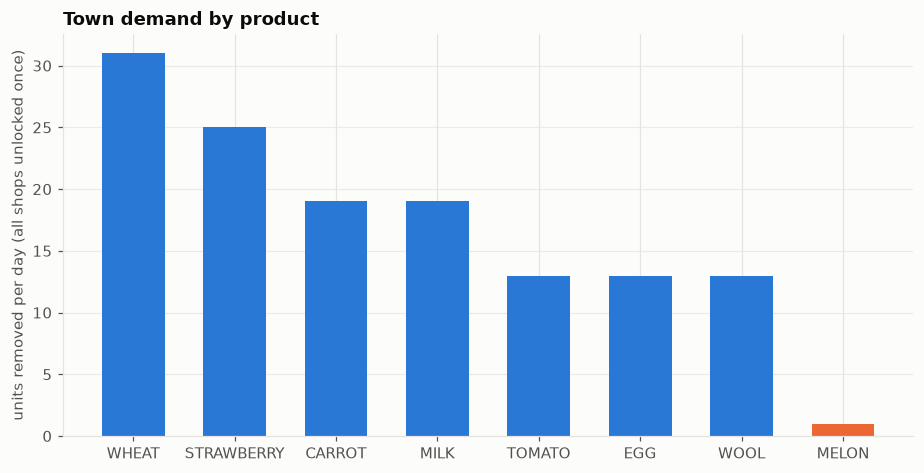

In [18]:
from kaggle_environments.envs.kaggriculture.kaggriculture import SHOPS

TURNS_PER_DAY, SHOP_INTERVAL = 24, 4
SHOPS_PER_DAY = TURNS_PER_DAY / SHOP_INTERVAL

# Demand if every shop were unlocked exactly once - the shape, not a forecast.
rows = []
for product in ("WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON", "EGG", "MILK", "WOOL"):
    pull = sum(2 if len(items) == 1 else 1
               for items in SHOPS.values() if product in items)
    shops_listing = [name for name, items in SHOPS.items() if product in items]
    rows.append((product, len(shops_listing), pull * SHOPS_PER_DAY + 1))

rows.sort(key=lambda r: -r[2])
print(f"{'product':<12}{'shops':>6}{'demand/day':>12}")
for product, n_shops, per_day in rows:
    flag = "   <-- no shop at all" if n_shops == 0 else ""
    print(f"{product:<12}{n_shops:>6}{per_day:>12.0f}{flag}")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
names = [r[0] for r in rows]
vals = [r[2] for r in rows]
colours = [SERIES[1] if r[1] == 0 else SERIES[0] for r in rows]
ax.bar(names, vals, color=colours, width=0.62)
ax.set_ylabel("units removed per day (all shops unlocked once)")
ax.set_title("Town demand by product", loc="left", fontweight="bold")
ax.grid(axis="y", color=GRID, linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

**MELON is in no shop at all.** Its only sink is the Town Centre's one unit a day
&mdash; roughly 30 units for an entire season &mdash; and the agent has been selling
around 180 into it. Carrot, by contrast, has `PET_CAFE` as a single-product (double
rate) shop.

`choose_crop` now divides our own incoming pipeline by market absorption **plus the
demand that will still arrive** before the season ends, read live from
`obs["town"]["unlocked_shops"]` rather than from the static table above. Measured in a
contested market that is worth **+3,358, winning 14 of 16 matches** &mdash; the largest
single change of the day.

One honest caveat: it did **not** work the way this reasoning predicts. Melon volume
barely moved (179 &rarr; 183 on the reference seed); what actually shifted was carrot
volume into strawberry. The change pays, and the mechanism story behind it is still
unconfirmed &mdash; so the melon oversupply above remains an open problem, not a solved
one.

## 9. Findings

Figures here come from `experiments/`, not from this notebook's small in-notebook
batches &mdash; those are demonstrations of mechanism, not numbers to act on.

**Self-play is the headline, and it is now ~34,000** (from 22,852 at the start of the
day). Against the built-ins the agent scores in the mid-40,000s and wins 12/12, but
those opponents never sell, so treat that as the ceiling case.

**Three changes moved it, each isolated head to head before being stacked.** A change
is only credited if it wins on its own:

| change | delta | wins |
|---|---|---|
| SHEEP instead of GOOSE | +1,332 | 15/16 |
| crew, 6 &rarr; 4 tiles per hand | +1,910 | 16/16 |
| demand-aware crop scoring | +3,358 | 14/16 |
| **combined, vs the previous agent** | **+12,698** | **14/16** |

**Judge changes with a paired or head-to-head comparison, never against the across-seed
stdev.** That spread (~2,000) measures how much *seasons* differ from each other; both
versions play the same seeds, so it cancels. Using it caused us to reject two real
gains &mdash; daily feeding (+1,657, 12/12) and fertilizer (+1,764, 12/12) were both
written off as noise before being re-measured properly.

**Use `head_to_head.py` for anything about selling.** The built-ins never sell, so a
market change looks free against them &mdash; and can point the *wrong way*, not merely
overstate. Moving liquidation from day 25 to day 19 measures **-440 against `starter`**
and **+617 head to head**. With nobody else selling, holding out for price is correct;
with a competitor in the same order book, selling late loses the race for demand.

**The crew is the binding constraint, not land.** The farm waters 19.2 tiles a day
against 24 planted &mdash; it cannot keep alive the ground it already holds, which is
why a denser crew pays and why `BUY_LAND` does not.

**On the ladder:** rank ~2,868 of 4,750, rating oscillating 528&ndash;616 and trending
up, against an unchanged control submission sitting at 470. Median is 743, so we are
still below it. Never read a single rating: every submission starts seeded at 600 and
drifts &plusmn;120.

## 10. Next steps

1. **The melon race.** Melon appears in no shop, so once its price is driven down it
   never recovers &mdash; which makes selling it a *race* rather than a market. Whoever
   sells first gets $250 a unit; whoever sells later gets $1. The day-19 liquidation
   result (+617, 21/24) is already one measurement pointing here. Selling melon early
   and hard on purpose, accepting a worse average ourselves to leave an opponent
   selling into a floor, is cheap to test and only `head_to_head.py` can price it.
2. **Why the demand model actually worked.** It pays (+3,358) but not for the stated
   reason &mdash; melon volume barely moved and carrot shifted into strawberry. Until
   that is understood, the melon oversupply is unexplained rather than fixed.
3. **Forward pricing** (`pricing.py`, verified against the engine across 738 points).
   The demand term above is the crudest possible version, a single number; a real
   forward model belongs there.
4. **Close the seed-budget leak.** The engine drops the *entire* `PLANT` request for a
   crop when a turn's demand exceeds seeds held &mdash; not a partial fill &mdash;
   costing roughly 43 unit-turns a season.
5. **More crew headroom.** Units spend 1,919 turns moving against 575 watering, with
   414 idle passes. `WORK_TILES_PER_HAND` 4 beat 6; 3 was tested and was not clearly
   better, so the remaining gain is in routing rather than headcount.

**Closed, don't re-run:** `BUY_LAND` (twice); more than one animal, including two
different species (-16,634, 0/16); diversifying off melon via `SELF_SUPPLY_EXPONENT`
(-6,883); smaller melon sell slices (-5,958); deliberate fertilizer trading (-1,486,
0/16 &mdash; the round trip is structurally break-even).